# HBV parameter calibration for temperature-dependent HBV model

To investigate whether warming changes $Su_{max}$, we set up an HBV model. Instead of a constant $Su_{max}$, we apply the following relationship: 
$$
Su_{max} = Su_{max, 0} + \gamma * (T-\Delta T)
$$

The analysis is carried out in two steps. First, we do a simple model where $Su_{max}$ changes daily. Then, we explore ways to model the slow-changing characteristic of soil parameters. Finally, we comment on the results. 

Plots used on the poster feature larger font sizes. 

In [94]:
import numpy as np
import pandas as pd 
import json
from hbv_bmi_project import HBV_Bmi
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

In [95]:
# Formatting for plots
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 26,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'lines.linewidth': 2.5,
    'lines.markersize': 9,
    'savefig.dpi': 300,
})

In [96]:
# Defining functions
if 'nse' not in globals():
    def nse(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        den = np.sum((obs - np.mean(obs)) ** 2)
        if den <= 0:
            return np.nan
        return 1 - np.sum((obs - sim) ** 2) / den

if 'log_nse' not in globals():
    def log_nse(obs, sim, eps=1e-6):
        obs = np.maximum(np.asarray(obs, dtype=float), eps)
        sim = np.maximum(np.asarray(sim, dtype=float), eps)
        return nse(np.log(obs), np.log(sim))

if 'rel_bias' not in globals():
    def rel_bias(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)
        s_obs = np.sum(obs)
        if s_obs == 0:
            return np.nan
        return (np.sum(sim) - s_obs) / s_obs

### Importing data and setting up Monte Carlo Simulations

In [ ]:
# # Import daily forcing data
# grdc_obs = pd.read_csv(
#     '6336500_Q_Day.Cmd.txt',
#     encoding='latin-1',
#     sep=';',
#     skiprows=36,
#     index_col=0,
#     parse_dates=True,
#     usecols=[0, 2],
# )
# grdc_obs.index.name = 'date'
# grdc_obs.columns = ['Observations from GRDC']

# shape_area = 28191724718

# base_path = globals().get('base', Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project')) ### change to local path

# # Read stitched daily CSVs
# p_daily_src = pd.read_csv(base_path / 'ERA5_daily_precip_1980-2025.csv')
# e_daily_src = pd.read_csv(base_path / 'ERA5_daily_evap_1980-2025.csv')

# for frame in (p_daily_src, e_daily_src):
#     frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%d')

# p_col = 'total_precipitation_daily'
# e_col = 'total_evaporation_daily'

# df_p_daily = p_daily_src.set_index('time')[[p_col]].rename(columns={p_col: 'precip_m_day'})
# df_e_daily = e_daily_src.set_index('time')[[e_col]].rename(columns={e_col: 'evap_m_day'})

# # Convert sentinel to NaN and keep daily regularity
# for frame, col in ((df_p_daily, 'precip_m_day'), (df_e_daily, 'evap_m_day')):
#     frame[col] = pd.to_numeric(frame[col], errors='coerce')
#     frame[col] = frame[col].replace(-9999, np.nan)

# # Overwrite df_p and df_e with clipped daily data for downstream use
# df_p = df_p_daily.copy()
# df_e = df_e_daily.copy()

# print('Daily precipitation range:', df_p.index.min(), 'to', df_p.index.max(), '| n =', len(df_p))
# print('Daily evaporation range:  ', df_e.index.min(), 'to', df_e.index.max(), '| n =', len(df_e))
# pd.concat([df_p.head(3), df_e.head(3)], axis=1)

Daily precipitation range: 1980-01-01 00:00:00 to 2025-12-31 00:00:00 | n = 16802
Daily evaporation range:   1980-01-01 00:00:00 to 2025-12-31 00:00:00 | n = 16802


,precip_m_day,evap_m_day
time,,
1980-01-01,0.000417,-0.000247
1980-01-02,0.001406,-0.000287
1980-01-03,0.001557,-0.000172


In [ ]:
# Explicit periods for Monte Carlo Simulations
start_spinup = pd.Timestamp('1980-01-01')
end_spinup = pd.Timestamp('1981-12-31')
start_cal = pd.Timestamp('1982-01-01')
end_cal = pd.Timestamp('2015-12-31')
start_val = pd.Timestamp('2016-01-01')
end_val = pd.Timestamp('2025-12-31')

start_mc = start_spinup
end_mc = end_cal

base_path = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project')
shape_area_local = float(globals().get('shape_area', 28191724718.0))
grdc_path_local = Path('/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt')

# Read stitched daily forcing CSVs (1980-2025), then clip to model windows
precip_daily_all = pd.read_csv(base_path / 'ERA5_daily_precip_1980-2025.csv')
evap_daily_all = pd.read_csv(base_path / 'ERA5_daily_evap_1980-2025.csv')
temp_daily_all = pd.read_csv(base_path / 'ERA5_daily_temp_1980-2025.csv')

for frame in (precip_daily_all, evap_daily_all, temp_daily_all):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%d')

precip_daily_all = precip_daily_all.set_index('time')
evap_daily_all = evap_daily_all.set_index('time')
temp_daily_all = temp_daily_all.set_index('time')

# Convert sentinel to NaN
precip_daily_all['total_precipitation_daily'] = pd.to_numeric(precip_daily_all['total_precipitation_daily'], errors='coerce').replace(-9999, np.nan)
evap_daily_all['total_evaporation_daily'] = pd.to_numeric(evap_daily_all['total_evaporation_daily'], errors='coerce').replace(-9999, np.nan)
temp_daily_all['temperature_2m'] = pd.to_numeric(temp_daily_all['temperature_2m'], errors='coerce').replace(-9999, np.nan)

daily_forcing = pd.DataFrame(index=pd.date_range(start_mc, end_mc, freq='D'))
daily_forcing['precip_m_day'] = precip_daily_all['total_precipitation_daily'].reindex(daily_forcing.index)
daily_forcing['evap_m_day'] = evap_daily_all['total_evaporation_daily'].reindex(daily_forcing.index)
daily_forcing['temp_K'] = temp_daily_all['temperature_2m'].reindex(daily_forcing.index)

# Fill occasional gaps in forcing
daily_forcing['precip_m_day'] = daily_forcing['precip_m_day'].interpolate(limit_direction='both')
daily_forcing['evap_m_day'] = daily_forcing['evap_m_day'].interpolate(limit_direction='both')
daily_forcing['temp_K'] = daily_forcing['temp_K'].interpolate(limit_direction='both')

# Convert forcing to model units
daily_forcing['pr_mm_day'] = daily_forcing['precip_m_day'] * 1000.0
daily_forcing['pet_mm_day'] = (-daily_forcing['evap_m_day']).clip(lower=0) * 1000.0
daily_forcing['temp_C'] = daily_forcing['temp_K'] - 273.15
daily_forcing['delT_C'] = daily_forcing['temp_C'] - daily_forcing['temp_C'].mean()

# Keep reusable daily temperature series for slow-dynamics/tau cells
temp_daily = (temp_daily_all['temperature_2m'] - 273.15).copy()

# Daily observed Q in mm/day (clipped to spin-up + calibration)
if 'grdc' not in globals():
    grdc = pd.read_csv(
        grdc_path_local,
        encoding='latin-1',
        sep=';',
        skiprows=36,
        index_col=0,
        parse_dates=True,
        usecols=[0, 2],
    )
    grdc.columns = ['q_m3s']
elif 'q_m3s' not in grdc.columns:
    grdc = grdc.copy()
    grdc.columns = ['q_m3s']

q_obs_daily = (
    grdc['q_m3s']
    .loc[start_mc:end_mc]
    .reindex(daily_forcing.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

# Explicit masks for spin-up, calibration, and validation periods
spinup_mask = (daily_forcing.index >= start_spinup) & (daily_forcing.index <= end_spinup)
cal_mask = (daily_forcing.index >= start_cal) & (daily_forcing.index <= end_cal)
val_mask_defined = (pd.date_range(start_val, end_val, freq='D') >= start_val)

# In-memory forcing DataArrays for hbv_bmi_project
pr_da_mc = xr.DataArray(daily_forcing['pr_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='pr')
pet_da_mc = xr.DataArray(daily_forcing['pet_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='evspsblpot')
tas_da_mc = xr.DataArray(daily_forcing['delT_C'].to_numpy(dtype=float), coords={'time': daily_forcing.index}, dims=('time',), name='tas')

print('MC forcing period:', daily_forcing.index.min(), 'to', daily_forcing.index.max(), '| n =', len(daily_forcing))
print('Spin-up period:', start_spinup.date(), 'to', end_spinup.date(), '| n =', int(spinup_mask.sum()))
print('Calibration period:', start_cal.date(), 'to', end_cal.date(), '| n =', int(cal_mask.sum()))
print('Validation period:', start_val.date(), 'to', end_val.date())
print('Input frequency (P/PET/T/Qobs): daily')
print('delT range (C):', float(np.nanmin(daily_forcing['delT_C'])), 'to', float(np.nanmax(daily_forcing['delT_C'])))

MC forcing period: 1980-01-01 00:00:00 to 2015-12-31 00:00:00 | n = 13149
Spin-up period: 1980-01-01 to 1981-12-31 | n = 731
Calibration period: 1982-01-01 to 2015-12-31 | n = 12418
Validation period: 2016-01-01 to 2025-12-31
Input frequency (P/PET/T/Qobs): daily
delT range (C): -23.862696340454832 to 19.417905221559167


### Part 1: Proof of concept: simple model, Su_max changes daily

Here, delT used in the simulations is calculated as daily temperature - long term average temperature of the basin.

In [ ]:
# MC simulation where Su_max changes daily
# a shorter TS used to limit computation time  
start_spinup = pd.Timestamp('2011-01-01')
end_spinup = pd.Timestamp('2011-12-31')
start_cal = pd.Timestamp('2012-01-01')
end_cal = pd.Timestamp('2014-12-31')
start_val = pd.Timestamp('2015-01-01')
end_val = pd.Timestamp('2017-12-31')

spinup_mask = (daily_forcing.index >= start_spinup) & (daily_forcing.index <= end_spinup)
cal_mask = (daily_forcing.index >= start_cal) & (daily_forcing.index <= end_cal)
val_mask_defined = (pd.date_range(start_val, end_val, freq='D') >= start_val)

#                      Imax, Ce, Sumax0,beta, Pmax, Tlag, Kf, Ks, Gamma
ParMinn_mc = np.array([0.0, 0.1, 50.0, 0.8, 0.001, 0.5, 0.01, 0.001, -0.03])
ParMaxn_mc = np.array([4.0, 1.2, 600.0, 4.0, 0.15, 6.0, 0.50, 0.05, 0.03])

N_mc = 1 # chagned to 1 run to prevent long run time. 1000 runs used during the project. 
results_mc = []

obs_cal = q_obs_daily[cal_mask]

for _ in range(N_mc):
    p = np.random.uniform(ParMinn_mc, ParMaxn_mc)

    cfg = {
        'precipitation_file': pr_da_mc,
        'potential_evaporation_file': pet_da_mc,
        'temperature_file': tas_da_mc,
        'T_baseline': 0.0,
        'initial_storage': '0.0,100.0,0.0,5.0',
    }

    m = HBV_Bmi()
    m.initialize(cfg)
    m.set_pars(p)

    sim = []
    while m.current_timestep < m.end_timestep:
        m.update()
        out = np.array([0.0])
        m.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    sim_cal = sim[cal_mask]
    nse_cal = nse(obs_cal, sim_cal)
    lognse_cal = log_nse(obs_cal, sim_cal)
    rb_cal = rel_bias(obs_cal, sim_cal)

    if np.isfinite(nse_cal) and np.isfinite(lognse_cal):
        results_mc.append({
            'params': p,
            'sim_mm_day': sim,
            'nse_cal': nse_cal,
            'lognse_cal': lognse_cal,
            'rb_cal': rb_cal,
        })

if not results_mc:
    raise RuntimeError('No valid daily MC runs found for 2011-2014.')

best_daily = max(results_mc, key=lambda d: d['nse_cal'])
sim_daily_best = best_daily['sim_mm_day']

summary_daily = pd.DataFrame({
    'metric': ['NSE_cal_2012_2014', 'logNSE_cal_2012_2014', 'rel_bias_cal_2012_2014'],
    'value': [best_daily['nse_cal'], best_daily['lognse_cal'], best_daily['rb_cal']],
})

print('Valid runs:', len(results_mc), '/', N_mc)
print('Best parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):')
print(best_daily['params'])
summary_daily

Valid runs: 10000 / 10000
Best parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):
[ 6.35448246e-01  3.89032324e-01  2.05200858e+02  2.19578225e+00
  1.45937953e-01  3.05467670e+00  2.08909475e-01  3.08610827e-02
 -3.99906846e-03]


,metric,value
0,NSE_cal_2012_2014,0.845237
1,logNSE_cal_2012_2014,0.604445
2,rel_bias_cal_2012_2014,-0.045743


Best parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):

[ 6.35448246e-01  3.89032324e-01  2.05200858e+02  2.19578225e+00
  1.45937953e-01  3.05467670e+00  2.08909475e-01  3.08610827e-02
 -3.99906846e-03]

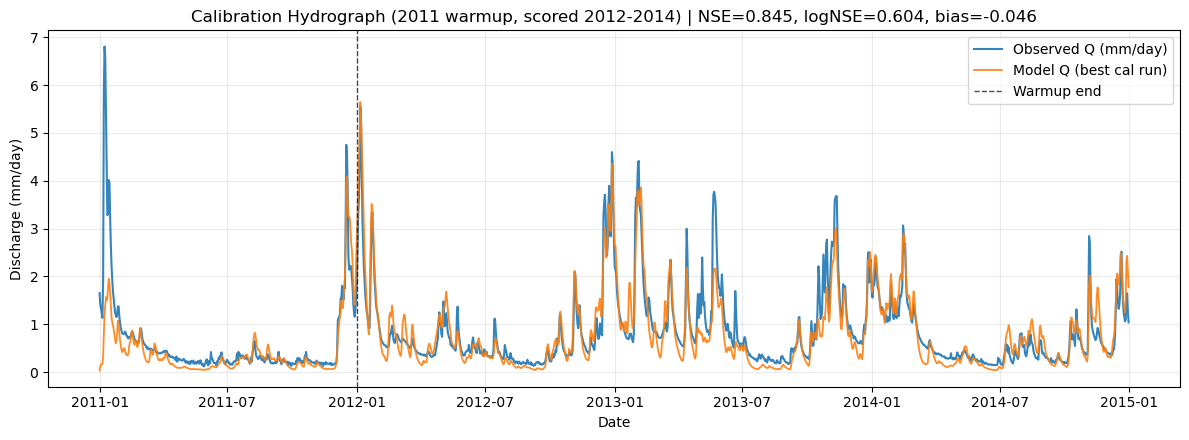

In [40]:
# Calibration hydrograph (forcing 2011-2014; metrics on 2012-2014 after warmup)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4.5))
plt.plot(daily_forcing.index, q_obs_daily, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(daily_forcing.index, sim_daily_best, label='Model Q (best cal run)', linewidth=1.3, alpha=0.9)
plt.axvline(pd.Timestamp('2012-01-01'), color='k', linestyle='--', linewidth=1.0, alpha=0.7, label='Warmup end')
plt.title(
    f'Calibration Hydrograph (2011 warmup, scored 2012-2014) | '
    f"NSE={best_daily['nse_cal']:.3f}, logNSE={best_daily['lognse_cal']:.3f}, bias={best_daily['rb_cal']:.3f}"
)
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [98]:
# Validation run with best calibrated parameters using stitched daily CSV inputs
start_val = pd.Timestamp('2015-01-01')
end_val = pd.Timestamp('2017-12-31')

# Load stitched daily forcing CSVs and clip to validation window
precip_daily_all = pd.read_csv(base_path / 'ERA5_daily_precip_1980-2025.csv')
evap_daily_all = pd.read_csv(base_path / 'ERA5_daily_evap_1980-2025.csv')
temp_daily_all = pd.read_csv(base_path / 'ERA5_daily_temp_1980-2025.csv')

for frame in (precip_daily_all, evap_daily_all, temp_daily_all):
    frame['time'] = pd.to_datetime(frame['system:index'].astype(str), format='%Y%m%d')

precip_daily_all = precip_daily_all.set_index('time')
evap_daily_all = evap_daily_all.set_index('time')
temp_daily_all = temp_daily_all.set_index('time')

precip_daily_all['total_precipitation_daily'] = pd.to_numeric(precip_daily_all['total_precipitation_daily'], errors='coerce').replace(-9999, np.nan)
evap_daily_all['total_evaporation_daily'] = pd.to_numeric(evap_daily_all['total_evaporation_daily'], errors='coerce').replace(-9999, np.nan)
temp_daily_all['temperature_2m'] = pd.to_numeric(temp_daily_all['temperature_2m'], errors='coerce').replace(-9999, np.nan)

daily_forcing_val = pd.DataFrame(index=pd.date_range(start_val, end_val, freq='D'))
daily_forcing_val['precip_m_day'] = precip_daily_all['total_precipitation_daily'].reindex(daily_forcing_val.index)
daily_forcing_val['evap_m_day'] = evap_daily_all['total_evaporation_daily'].reindex(daily_forcing_val.index)
daily_forcing_val['temp_K'] = temp_daily_all['temperature_2m'].reindex(daily_forcing_val.index)

daily_forcing_val['precip_m_day'] = daily_forcing_val['precip_m_day'].interpolate(limit_direction='both')
daily_forcing_val['evap_m_day'] = daily_forcing_val['evap_m_day'].interpolate(limit_direction='both')
daily_forcing_val['temp_K'] = daily_forcing_val['temp_K'].interpolate(limit_direction='both')

daily_forcing_val['pr_mm_day'] = daily_forcing_val['precip_m_day'] * 1000.0
daily_forcing_val['pet_mm_day'] = (-daily_forcing_val['evap_m_day']).clip(lower=0) * 1000.0
daily_forcing_val['temp_C'] = daily_forcing_val['temp_K'] - 273.15
daily_forcing_val['delT_C'] = daily_forcing_val['temp_C'] - daily_forcing_val['temp_C'].mean()

q_obs_val = (
    grdc['q_m3s']
    .loc[start_val:end_val]
    .reindex(daily_forcing_val.index)
    .interpolate(limit_direction='both')
    .to_numpy(dtype=float)
    * 86400.0 / shape_area_local * 1000.0
)

if pd.infer_freq(daily_forcing_val.index) != 'D':
    raise ValueError('Validation forcing index is not daily.')

pr_da_val = xr.DataArray(daily_forcing_val['pr_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='pr')
pet_da_val = xr.DataArray(daily_forcing_val['pet_mm_day'].to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='evspsblpot')
tas_da_val = xr.DataArray(daily_forcing_val['delT_C'].to_numpy(dtype=float), coords={'time': daily_forcing_val.index}, dims=('time',), name='tas')

if 'best_daily' not in globals():
    csv_candidates = ['results_mc.csv', 'results_mc_slow.csv']
    required_cols = {'Imax', 'Ce', 'Sumax0', 'beta', 'Pmax', 'Tlag', 'Kf', 'Ks', 'Gamma', 'nse_cal', 'lognse_cal', 'rb_cal'}
    loaded = False

    for csv_path in csv_candidates:
        try:
            df_params = pd.read_csv(csv_path)
        except FileNotFoundError:
            continue

        if df_params.empty or not required_cols.issubset(df_params.columns):
            continue

        best_row = df_params.sort_values('nse_cal', ascending=False).iloc[0]
        best_daily = {
            'params': np.array([
                best_row['Imax'],
                best_row['Ce'],
                best_row['Sumax0'],
                best_row['beta'],
                best_row['Pmax'],
                best_row['Tlag'],
                best_row['Kf'],
                best_row['Ks'],
                best_row['Gamma'],
            ], dtype=float),
            'nse_cal': float(best_row['nse_cal']),
            'lognse_cal': float(best_row['lognse_cal']),
            'rb_cal': float(best_row['rb_cal']),
        }
        loaded = True
        print(f"Loaded best_daily parameters from {csv_path}")
        break

    if not loaded:
        raise RuntimeError('best_daily is missing and no compatible results CSV was found (checked results_mc.csv, results_mc_slow.csv).')

cfg_val = {
    'precipitation_file': pr_da_val,
    'potential_evaporation_file': pet_da_val,
    'temperature_file': tas_da_val,
    'T_baseline': 0.0,
    'initial_storage': '0.0,100.0,0.0,5.0',
}

m_val = HBV_Bmi()
m_val.initialize(cfg_val)
m_val.set_pars(best_daily['params'])

sim_val = []
while m_val.current_timestep < m_val.end_timestep:
    m_val.update()
    out = np.array([0.0])
    m_val.get_value('Q', out)
    sim_val.append(out[0])
sim_val = np.asarray(sim_val, dtype=float)

nse_val = nse(q_obs_val, sim_val)
lognse_val = log_nse(q_obs_val, sim_val)
rb_val = rel_bias(q_obs_val, sim_val)

summary_val = pd.DataFrame({
    'metric': ['NSE_val_2015_2016', 'logNSE_val_2015_2016', 'rel_bias_val_2015_2016'],
    'value': [nse_val, lognse_val, rb_val],
})

print('Validation period:', daily_forcing_val.index.min(), 'to', daily_forcing_val.index.max(), '| n =', len(daily_forcing_val))
print('Input frequency (P/PET/T/Qobs): daily')
summary_val

Validation period: 2015-01-01 00:00:00 to 2017-12-31 00:00:00 | n = 1096
Input frequency (P/PET/T/Qobs): daily


,metric,value
0,NSE_val_2015_2016,0.679207
1,logNSE_val_2015_2016,0.197236
2,rel_bias_val_2015_2016,-0.272585


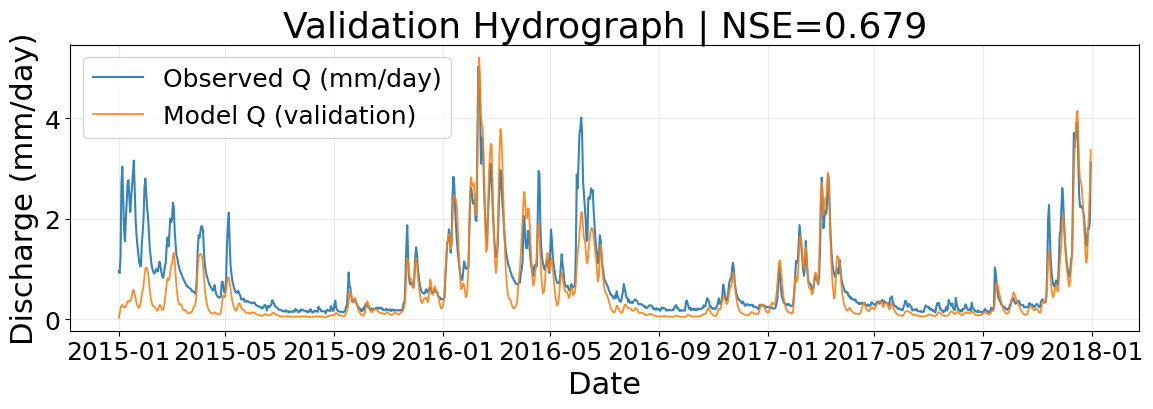

In [17]:
# Validation hydrograph
plt.figure(figsize=(12, 4.5))
plt.plot(daily_forcing_val.index, q_obs_val, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(daily_forcing_val.index, sim_val, label='Model Q (validation)', linewidth=1.3, alpha=0.9)
plt.title(f'Validation Hydrograph | NSE={nse_val:.3f}')
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

From the NSE and visual inspection of the graphs, it seems that the calibrated model is a reasonable fit. The best calibrated $\gamma$ is $-4E-3$, which indicates temperature has a negative relationship with $Su_{max}$, matching our expectations. 

### Part 2: Using 5-year moving average temperature for $Su_{max}$

However, physically soil properties do not respond to daily changes in temperature. They reflect a long term change in temperature, so there is a need for an alternative way to model the temperature-$Su_{max}$ relationship. As there is no readily available model, we decided to start with a simple moving average of 5 years. A 5-year moving average was chosen as it is long enough to assume that sustained warming could have some effect on soil, also reasonable compared to the scale of the entire time series (40 years). 

In the following simulations, `delT_C` is replaced with `delT_slow_C`, using a 5-year moving average of temperature - long term averge of basin temperature.

In [65]:
# Build slow temperature anomaly for calibration period (5-year moving average)
if 'daily_forcing' not in globals():
    raise RuntimeError('Run the daily setup cell first so daily_forcing exists.')

window_days = 365 * 5  # 5-year trailing window
daily_forcing_slow = daily_forcing.copy()
daily_forcing_slow['temp_slow_C'] = daily_forcing_slow['temp_C'].rolling(
    window=window_days,
    min_periods=1
).mean()
daily_forcing_slow['delT_slow_C'] = daily_forcing_slow['temp_slow_C'] - daily_forcing_slow['temp_slow_C'].mean()

tas_da_mc_slow = xr.DataArray(
    daily_forcing_slow['delT_slow_C'].to_numpy(dtype=float),
    coords={'time': daily_forcing_slow.index},
    dims=('time',),
    name='tas',
)

In [31]:
from tqdm.notebook import tqdm  # Add this import
# MC calibration using slow-dynamics gamma (same periods and bounds)
if 'cal_mask' not in globals() or 'q_obs_daily' not in globals() or 'pr_da_mc' not in globals() or 'pet_da_mc' not in globals():
    raise RuntimeError('Run the daily setup cell first (it defines forcing and calibration masks).')

if 'nse' not in globals() or 'log_nse' not in globals() or 'rel_bias' not in globals():
    raise RuntimeError('Run the MC metric-definition cell first (nse/log_nse/rel_bias).')

# Reuse current bounds if present; otherwise define defaults
if 'ParMinn_mc' not in globals() or 'ParMaxn_mc' not in globals():
    ParMinn_mc = np.array([0.0, 0.1, 50.0, 0.8, 0.001, 0.5, 0.01, 0.001, -0.03])
    ParMaxn_mc = np.array([4.0, 1.2, 600.0, 4.0, 0.15, 6.0, 0.50, 0.05, 0.03])

N_mc_slow = 1000
results_mc_slow = []
obs_cal = q_obs_daily[cal_mask]

# Add progress bar to the loop
for _ in tqdm(range(N_mc_slow), desc="Monte Carlo Calibration", unit="run"):
    p = np.random.uniform(ParMinn_mc, ParMaxn_mc)
    cfg_slow = {
        'precipitation_file': pr_da_mc,
        'potential_evaporation_file': pet_da_mc,
        'temperature_file': tas_da_mc_slow,
        'T_baseline': 0.0,
        'initial_storage': '0.0,100.0,0.0,5.0',
    }

    m_slow = HBV_Bmi()
    m_slow.initialize(cfg_slow)
    m_slow.set_pars(p)

    sim = []
    while m_slow.current_timestep < m_slow.end_timestep:
        m_slow.update()
        out = np.array([0.0])
        m_slow.get_value('Q', out)
        sim.append(out[0])

    sim = np.asarray(sim, dtype=float)
    if (not np.all(np.isfinite(sim))) or np.any(sim < 0):
        continue

    sim_cal = sim[cal_mask]
    nse_cal = nse(obs_cal, sim_cal)
    lognse_cal = log_nse(obs_cal, sim_cal)
    rb_cal = rel_bias(obs_cal, sim_cal)

    if np.isfinite(nse_cal) and np.isfinite(lognse_cal):
        results_mc_slow.append({
            'params': p,
            'sim_mm_day': sim,
            'nse_cal': nse_cal,
            'lognse_cal': lognse_cal,
            'rb_cal': rb_cal,
        })

if not results_mc_slow:
    raise RuntimeError('No valid slow-gamma MC runs found.')

best_daily_slow = max(results_mc_slow, key=lambda d: d['nse_cal'])
sim_daily_best_slow = best_daily_slow['sim_mm_day']

summary_daily_slow = pd.DataFrame({
    'metric': ['NSE_cal_2012_2014_slowGamma', 'logNSE_cal_2012_2014_slowGamma', 'rel_bias_cal_2012_2014_slowGamma'],
    'value': [best_daily_slow['nse_cal'], best_daily_slow['lognse_cal'], best_daily_slow['rb_cal']],
})

print('Valid slow-gamma runs:', len(results_mc_slow), '/', N_mc_slow)
print('Best slow-gamma parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):')
print(best_daily_slow['params'])
summary_daily_slow

Monte Carlo Calibration:   0%|          | 0/1000 [00:00<?, ?run/s]

Valid slow-gamma runs: 1000 / 1000
Best slow-gamma parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):
[2.81465763e+00 4.87180419e-01 3.01718767e+02 3.46980507e+00
 1.31329391e-01 4.11024485e+00 3.14562905e-01 4.39521527e-02
 1.47089227e-02]


,metric,value
0,NSE_cal_2012_2014_slowGamma,0.848650
1,logNSE_cal_2012_2014_slowGamma,0.423133
2,rel_bias_cal_2012_2014_slowGamma,-0.132471


Best slow-gamma parameters (Imax, Ce, Sumax0, beta, Pmax, Tlag, Kf, Ks, Gamma):

[2.81465763e+00 4.87180419e-01 3.01718767e+02 3.46980507e+00
 1.31329391e-01 4.11024485e+00 3.14562905e-01 4.39521527e-02
 1.47089227e-02]

In [ ]:
# Extract only the scalar values (not the full sim_mm_day array)
results_summary = []
for result in results_mc_slow:
    results_summary.append({
        'nse_cal': result['nse_cal'],
        'lognse_cal': result['lognse_cal'],
        'rb_cal': result['rb_cal'],
        'Imax': result['params'][0],
        'Ce': result['params'][1],
        'Sumax0': result['params'][2],
        'beta': result['params'][3],
        'Pmax': result['params'][4],
        'Tlag': result['params'][5],
        'Kf': result['params'][6],
        'Ks': result['params'][7],
        'Gamma': result['params'][8]
    })

# Convert to DataFrame and save
df_results = pd.DataFrame(results_summary)
df_results.to_csv('results_mc_slow.csv', index=False)

print(f"Saved {len(df_results)} runs to results_mc_slow.csv")
print(f"Columns: {list(df_results.columns)}")

Saved 1000 runs to results_mc_slow.csv
Columns: ['nse_cal', 'lognse_cal', 'rb_cal', 'Imax', 'Ce', 'Sumax0', 'beta', 'Pmax', 'Tlag', 'Kf', 'Ks', 'Gamma']


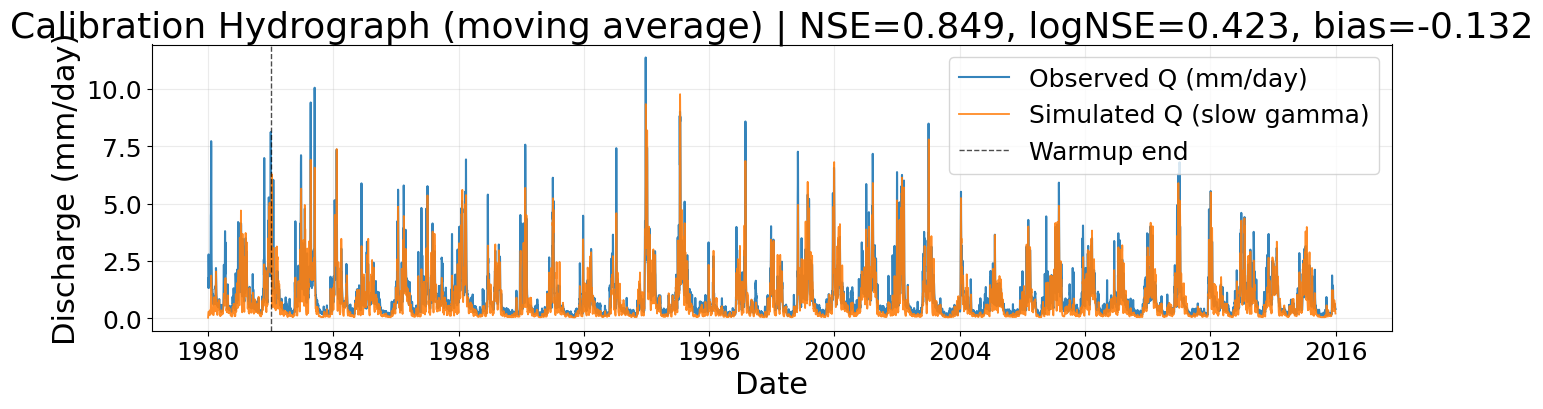

In [ ]:
# Plot observed vs simulated calibration values for the slow-dynamics gamma run
if 'best_daily_slow' not in globals():
    results_mc_slow = pd.read_csv('results_mc_slow.csv')
    if results_mc_slow.empty:
        raise RuntimeError("results_mc_slow.csv is empty; run slow-gamma calibration first.")

    # import saved run results
    best_row = df_results.sort_values('nse_cal', ascending=False).iloc[0]
    best_daily_slow = {
        'params': np.array([
            best_row['Imax'],
            best_row['Ce'],
            best_row['Sumax0'],
            best_row['beta'],
            best_row['Pmax'],
            best_row['Tlag'],
            best_row['Kf'],
            best_row['Ks'],
            best_row['Gamma'],
        ], dtype=float),
        'nse_cal': float(best_row['nse_cal']),
        'lognse_cal': float(best_row['lognse_cal']),
        'rb_cal': float(best_row['rb_cal']),
    }

if 'daily_forcing' not in globals() or 'q_obs_daily' not in globals():
    raise RuntimeError('Run the daily setup cell first so daily_forcing and q_obs_daily exist.')

if 'sim_daily_best_slow' not in globals():
    if 'pr_da_mc' not in globals() or 'pet_da_mc' not in globals():
        raise RuntimeError('Missing pr_da_mc or pet_da_mc. Run the daily setup cell first.')

    tas_input = tas_da_mc_slow if 'tas_da_mc_slow' in globals() else tas_da_mc

    cfg_rebuild = {
        'precipitation_file': pr_da_mc,
        'potential_evaporation_file': pet_da_mc,
        'temperature_file': tas_input,
        'T_baseline': 0.0,
        'initial_storage': '0.0,100.0,0.0,5.0',
    }

    m_rebuild = HBV_Bmi()
    m_rebuild.initialize(cfg_rebuild)
    m_rebuild.set_pars(best_daily_slow['params'])

    sim_rebuild = []
    while m_rebuild.current_timestep < m_rebuild.end_timestep:
        m_rebuild.update()
        out = np.array([0.0])
        m_rebuild.get_value('Q', out)
        sim_rebuild.append(out[0])

    sim_daily_best_slow = np.asarray(sim_rebuild, dtype=float)

plt.figure(figsize=(14, 4.5))
plt.plot(daily_forcing.index, q_obs_daily, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(daily_forcing.index, sim_daily_best_slow, label='Simulated Q (slow gamma)', linewidth=1.3, alpha=0.9)
plt.axvline(pd.Timestamp('1982-01-01'), color='k', linestyle='--', linewidth=1.0, alpha=0.7, label='Warmup end')
plt.title(
    f"Calibration Hydrograph (moving average) | NSE={best_daily_slow['nse_cal']:.3f}, "
    f"logNSE={best_daily_slow['lognse_cal']:.3f}, bias={best_daily_slow['rb_cal']:.3f}"
)
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Validation with slow-dynamics gamma
start_val = pd.Timestamp('2016-01-01')
end_val = pd.Timestamp('2025-12-31')

daily_forcing_val = pd.DataFrame(index=pd.date_range(start_val, end_val, freq='D'))
daily_forcing_val['precip_m_day'] = precip_daily_all['total_precipitation_daily'].reindex(daily_forcing_val.index)
daily_forcing_val['evap_m_day'] = evap_daily_all['total_evaporation_daily'].reindex(daily_forcing_val.index)
daily_forcing_val['temp_K'] = temp_daily_all['temperature_2m'].reindex(daily_forcing_val.index)

daily_forcing_val['precip_m_day'] = daily_forcing_val['precip_m_day'].interpolate(limit_direction='both')
daily_forcing_val['evap_m_day'] = daily_forcing_val['evap_m_day'].interpolate(limit_direction='both')
daily_forcing_val['temp_K'] = daily_forcing_val['temp_K'].interpolate(limit_direction='both')

daily_forcing_val['pr_mm_day'] = daily_forcing_val['precip_m_day'] * 1000.0
daily_forcing_val['pet_mm_day'] = (-daily_forcing_val['evap_m_day']).clip(lower=0) * 1000.0
daily_forcing_val['temp_C'] = daily_forcing_val['temp_K'] - 273.15
daily_forcing_val['delT_C'] = daily_forcing_val['temp_C'] - daily_forcing_val['temp_C'].mean()

# Build slow temperature over a longer continuous index to avoid edge effects at validation start
slow_full_index = pd.date_range(start=daily_forcing.index.min(), end=daily_forcing_val.index.max(), freq='D')
temp_full = temp_daily.reindex(slow_full_index).interpolate(limit_direction='both')
window_days = 365 * 5
temp_slow_full = temp_full.rolling(window=window_days, min_periods=1).mean()
temp_slow_val = temp_slow_full.reindex(daily_forcing_val.index)

daily_forcing_val_slow = daily_forcing_val.copy()
daily_forcing_val_slow['temp_slow_C'] = temp_slow_val.to_numpy()
daily_forcing_val_slow['delT_slow_C'] = daily_forcing_val_slow['temp_slow_C'] - daily_forcing_val_slow['temp_slow_C'].mean()

tas_da_val_slow = xr.DataArray(
    daily_forcing_val_slow['delT_slow_C'].to_numpy(dtype=float),
    coords={'time': daily_forcing_val_slow.index},
    dims=('time',),
    name='tas',
)

cfg_val_slow = {
    'precipitation_file': pr_da_val,
    'potential_evaporation_file': pet_da_val,
    'temperature_file': tas_da_val_slow,
    'T_baseline': 0.0,
    'initial_storage': '0.0,100.0,0.0,5.0',
}

m_val_slow = HBV_Bmi()
m_val_slow.initialize(cfg_val_slow)
m_val_slow.set_pars(best_daily_slow['params'])

sim_val_slow = []
while m_val_slow.current_timestep < m_val_slow.end_timestep:
    m_val_slow.update()
    out = np.array([0.0])
    m_val_slow.get_value('Q', out)
    sim_val_slow.append(out[0])
sim_val_slow = np.asarray(sim_val_slow, dtype=float)

nse_val_slow = nse(q_obs_val, sim_val_slow)
lognse_val_slow = log_nse(q_obs_val, sim_val_slow)
rb_val_slow = rel_bias(q_obs_val, sim_val_slow)

summary_val_slow = pd.DataFrame({
    'metric': ['NSE_val_slowGamma', 'logNSE_val_slowGamma', 'rel_bias_val_slowGamma'],
    'value': [nse_val_slow, lognse_val_slow, rb_val_slow],
})

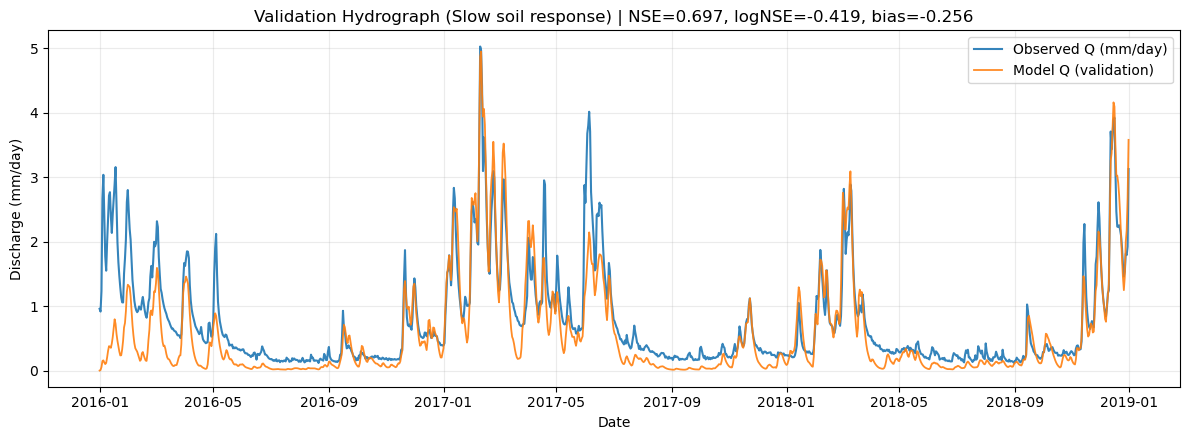

In [29]:
# Validation hydrograph
n_plot = min(len(daily_forcing_val.index), len(q_obs_val), len(sim_val_slow))
plot_index = daily_forcing_val.index[:n_plot]
plot_obs = q_obs_val[:n_plot]
plot_sim = sim_val_slow[:n_plot]

plt.figure(figsize=(12, 4.5))
plt.plot(plot_index, plot_obs, label='Observed Q (mm/day)', linewidth=1.5, alpha=0.9)
plt.plot(plot_index, plot_sim, label='Model Q (validation)', linewidth=1.3, alpha=0.9)
plt.title(f'Validation Hydrograph (Slow soil response) | NSE={nse_val_slow:.3f}, logNSE={lognse_val_slow:.3f}, bias={rb_val_slow:.3f}')
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

To probe into the uncertainty of calibrated HBV parameters, we look at the top 5 best sets of parameters: 

In [23]:
# Sort results by NSE in descending order and get top 5
if 'results_mc_slow' not in globals():
    results_mc_slow = pd.read_csv('results_mc_slow.csv')

if isinstance(results_mc_slow, pd.DataFrame):
    required_cols = {'Imax', 'Ce', 'Sumax0', 'beta', 'Pmax', 'Tlag', 'Kf', 'Ks', 'Gamma', 'nse_cal', 'lognse_cal', 'rb_cal'}
    if results_mc_slow.empty or not required_cols.issubset(results_mc_slow.columns):
        raise RuntimeError('results_mc_slow.csv is missing required columns for top-5 extraction.')

    top5_df = results_mc_slow.sort_values('nse_cal', ascending=False).head(5).copy()
    top_5 = [{
        'params': np.array([
            row['Imax'], row['Ce'], row['Sumax0'], row['beta'], row['Pmax'],
            row['Tlag'], row['Kf'], row['Ks'], row['Gamma']
        ], dtype=float),
        'nse_cal': float(row['nse_cal']),
        'lognse_cal': float(row['lognse_cal']),
        'rb_cal': float(row['rb_cal']),
    } for _, row in top5_df.iterrows()]
else:
    top_5 = sorted(results_mc_slow, key=lambda x: x['nse_cal'], reverse=True)[:5]

# Convert top_5 to DataFrame
df_top5 = pd.DataFrame([{
    'Rank': i,
    'Imax': r['params'][0],
    'Ce': r['params'][1],
    'Sumax0': r['params'][2],
    'beta': r['params'][3],
    'Pmax': r['params'][4],
    'Tlag': r['params'][5],
    'Kf': r['params'][6],
    'Ks': r['params'][7],
    'Gamma': r['params'][8],
    'NSE': r['nse_cal'],
    'LogNSE': r['lognse_cal'],
    'Rel_Bias': r['rb_cal'],
} for i, r in enumerate(top_5, 1)])
df_top5

,Rank,Imax,Ce,Sumax0,beta,Pmax,Tlag,Kf,Ks,Gamma,NSE,LogNSE,Rel_Bias
0,1,2.814658,0.487180,301.718767,3.469805,0.131329,4.110245,0.314563,0.043952,0.014709,0.848650,0.423133,-0.132471
1,2,1.146811,0.303073,211.885638,1.564548,0.142651,3.636817,0.224940,0.019242,-0.014713,0.848459,0.642935,-0.073657
2,3,0.446847,0.598158,448.927753,3.517191,0.141681,3.493934,0.271378,0.018942,0.001135,0.842785,0.746244,-0.025673
3,4,1.572276,0.395590,216.523003,2.988581,0.144795,3.691856,0.337682,0.049101,0.017138,0.837634,0.093822,-0.171692
4,5,2.156808,0.311803,180.474393,1.813446,0.050302,3.624968,0.238800,0.034909,0.007885,0.835894,0.076207,-0.134753


There is quite a wide range of gamma values, including both positive and negative. However, gamma is a always very small, which suggests that temperature does not have a very strong correlation with Su_max. 

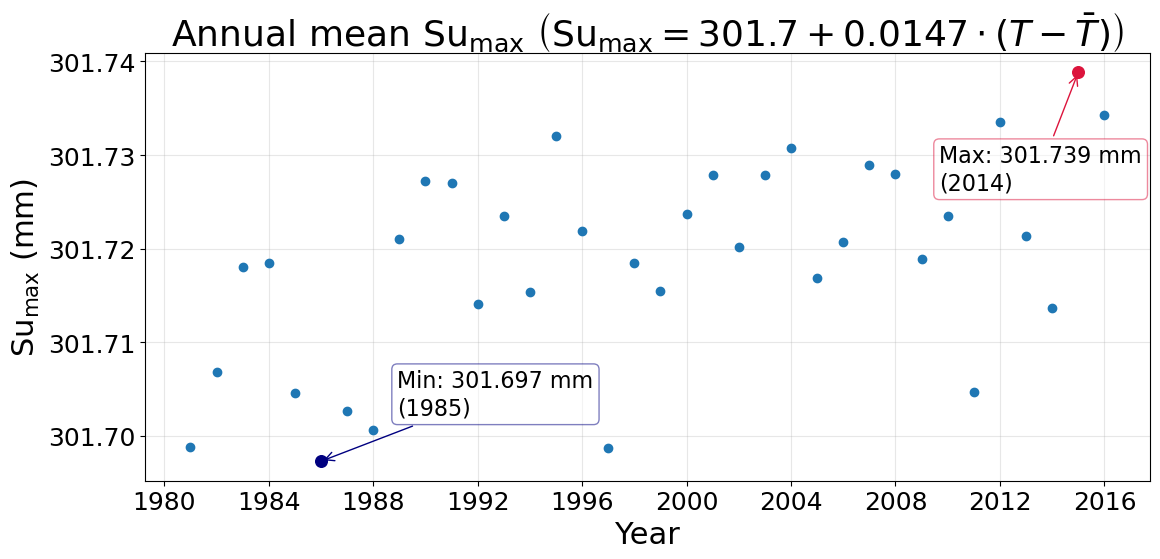

In [85]:
# plot Su_max against temperature anamoly
best_Sumax0 = best_daily_slow['params'][2]
best_gamma = best_daily_slow['params'][8]

tests = daily_forcing.copy()
tests['ts_Sumax'] = best_Sumax0 + best_gamma * daily_forcing['delT_C']
annual_means = tests['ts_Sumax'].resample("YE").mean()

# Find min/max annual Su_max
idx_max = annual_means.idxmax()
idx_min = annual_means.idxmin()
val_max = float(annual_means.loc[idx_max])
val_min = float(annual_means.loc[idx_min])


# Plot annual means against time (not against daily index)
plt.figure(figsize=(12, 6))
plt.plot(annual_means.index, annual_means.values, 'o', linewidth=2, markersize=6)

# Highlight points
plt.scatter([idx_max], [val_max], color='crimson', s=70, zorder=5, label='Max Su_max')
plt.scatter([idx_min], [val_min], color='navy', s=70, zorder=5, label='Min Su_max')

# Annotate values
plt.annotate(
    f"Max: {val_max:.3f} mm\n({idx_max.year})",
    xy=(idx_max, val_max),
    xytext=(-100, -84),
    textcoords="offset points",
    fontsize=16,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="crimson", alpha=0.5),
    arrowprops=dict(arrowstyle="->", color="crimson", lw=1.0),
)
plt.annotate(
    f"Min: {val_min:.3f} mm\n({idx_min.year})",
    xy=(idx_min, val_min),
    xytext=(55, 34),
    textcoords="offset points",
    fontsize=16,
    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="navy", alpha=0.5),
    arrowprops=dict(arrowstyle="->", color="navy", lw=1.0),
) 
plt.xlabel('Year')
plt.ylabel(r'$\mathrm{Su_{max}}$ (mm)')
plt.title(rf'$\mathrm{{Annual \ mean \ Su_{{max}}}}$ $\left( \mathrm{{Su_{{max}}}} = {best_Sumax0:.1f} + {best_gamma:.4f} \cdot (T - \bar{{T}}) \right)$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Using the best results from the MC calibration run with a positive $\gamma$, $Su_{max}$ follows a linear relationship with temperature, so visually $Su_{max}$ seems to see a rising trend as warming is observed in general. However, the magnitude of change is almost negligible - there is only a 0.04mm difference, 

1982 mean ΔT = -0.050 °C


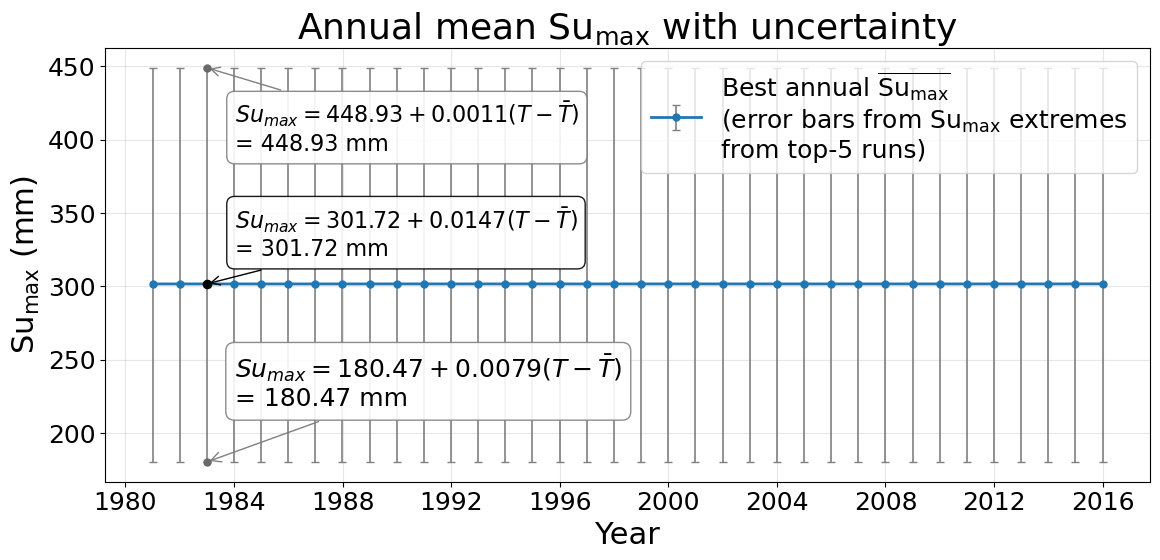

,year,mean_dT_C,Su_best_mm,Su_high_from_max_Su_max0_mm,Su_low_from_min_Su_max0_mm
0,1980,-1.357217,301.698804,448.926213,180.463691
1,1981,-0.814521,301.706786,448.926829,180.467971
2,1982,-0.049784,301.718035,448.927697,180.474001
3,1983,-0.017122,301.718515,448.927734,180.474258
4,1984,-0.960648,301.704637,448.926663,180.466818
5,1985,-1.459544,301.697299,448.926097,180.462884
6,1986,-1.095207,301.702658,448.926510,180.465757
7,1987,-1.235084,301.700600,448.926352,180.464654
8,1988,0.155438,301.721053,448.927929,180.475619
9,1989,0.573518,301.727203,448.928404,180.478916


In [50]:
# Annual Su_max with uncertainty from top-5 parameter spread (by Su_max0 extremes)
if 'top_5' not in globals() or len(top_5) < 5:
    raise RuntimeError("Run the top_5 cell first (need at least 5 runs).")
if 'best_daily_slow' not in globals():
    raise RuntimeError("Run slow calibration first so best_daily_slow exists.")
if 'daily_forcing' not in globals() or 'delT_C' not in daily_forcing.columns:
    raise RuntimeError("Run forcing setup first so daily_forcing['delT_C'] exists.")

# 1) For each year: mean temperature anomaly
ann_dT = daily_forcing['delT_C'].resample('YE').mean().rename('dT_mean')

# 2) max error bar = top-5 set with largest Su_max0
r_hi = max(top_5, key=lambda r: float(r['params'][2]))   # largest Sumax0
S0_hi = float(r_hi['params'][2])
g_hi = float(r_hi['params'][8])

# 3) min error bar = top-5 set with lowest Su_max0
r_lo = min(top_5, key=lambda r: float(r['params'][2]))   # lowest Sumax0
S0_lo = float(r_lo['params'][2])
g_lo = float(r_lo['params'][8])

# 4) best fit = best parameters
S0_best = float(best_daily_slow['params'][2])
g_best = float(best_daily_slow['params'][8])

# Build annual Su_max series from annual mean temperature anomaly
su_best = S0_best + g_best * ann_dT
su_hi = S0_hi + g_hi * ann_dT
su_lo = S0_lo + g_lo * ann_dT

# Align and ensure lower/upper envelopes
df_plot = pd.concat([ann_dT, su_best.rename('best'), su_hi.rename('hi'), su_lo.rename('lo')], axis=1).dropna()
lower = np.minimum(df_plot['hi'].values, df_plot['lo'].values)
upper = np.maximum(df_plot['hi'].values, df_plot['lo'].values)
center = df_plot['best'].values

yerr = np.vstack([center - lower, upper - center])  # asymmetric error bars

plt.figure(figsize=(12, 6))
plt.errorbar(
    df_plot.index,
    center,
    yerr=yerr,
    fmt='o-',
    linewidth=2,
    markersize=5,
    capsize=3,
    ecolor='gray',
    elinewidth=1.2,
    label = r'Best annual $\overline{\mathrm{Su_{max}}}$' + '\n' + r'(error bars from $\mathrm{Su_{max}}$ extremes'  + '\n' + 'from top-5 runs)'
)

# --- 1988 numeric annotation ---
yr = pd.Timestamp("1982-12-31")
if yr in df_plot.index:
    dT_1982 = float(df_plot.loc[yr, 'dT_mean'])
    b_1982 = float(df_plot.loc[yr, 'best'])
    h_1982 = float(df_plot.loc[yr, 'hi'])
    l_1982 = float(df_plot.loc[yr, 'lo'])

    up_1982 = max(h_1982, l_1982)
    lo_1982 = min(h_1982, l_1982)

    plt.scatter([yr], [b_1982], color='black', s=35, zorder=5)
    plt.scatter([yr], [up_1982], color='dimgray', s=25, zorder=5)
    plt.scatter([yr], [lo_1982], color='dimgray', s=25, zorder=5)

    # 3 separate labels
    label_best = (
        rf"$Su_{{max}} = {S0_best:.2f} + {g_best:.4f}(T-\bar{{T}})$"
        f"\n= {b_1982:.2f} mm"
    )
    label_high = (
        rf"$Su_{{max}} = {S0_hi:.2f} + {g_hi:.4f}(T-\bar{{T}})$"
        f"\n= {h_1982:.2f} mm"
    )
    label_low = (
        rf"$Su_{{max}} = {S0_lo:.2f} + {g_lo:.4f}(T-\bar{{T}})$"
        f"\n= {l_1982:.2f} mm"
    )
    plt.annotate(
        label_best,
        xy=(yr, b_1982),
        xytext=(20, 20),
        textcoords="offset points",
        fontsize=16,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", alpha=0.9),
        arrowprops=dict(arrowstyle="->", color="black", lw=1.0),
    )
    plt.annotate(
        label_high,
        xy=(yr, up_1982),
        xytext=(20, -60),
        textcoords="offset points",
        fontsize=16,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray", alpha=0.9),
        arrowprops=dict(arrowstyle="->", color="gray", lw=1.0),
    )
    plt.annotate(
        label_low,
        xy=(yr, lo_1982),
        xytext=(20, 40),
        textcoords="offset points",
        fontsize=18,
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="gray", alpha=0.9),
        arrowprops=dict(arrowstyle="->", color="gray", lw=1.0),
    )

    print(f"1982 mean ΔT = {dT_1982:.3f} °C")

plt.xlabel('Year')
plt.ylabel(r'$\mathrm{Su_{max}}$ (mm)')
plt.title(r'Annual mean $\mathrm{Su_{max}}$ with uncertainty')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional table
pd.DataFrame({
    'year': df_plot.index.year,
    'mean_dT_C': df_plot['dT_mean'].values,
    'Su_best_mm': df_plot['best'].values,
    'Su_high_from_max_Su_max0_mm': df_plot['hi'].values,
    'Su_low_from_min_Su_max0_mm': df_plot['lo'].values,
})

In the plot above, we can see that the fluctuations in $Su_{max}$ is insignificant compared to its uncertainty, due to the large range of $Su_{max,0}$ and $\gamma$ values among the top 5 calibration runs. 

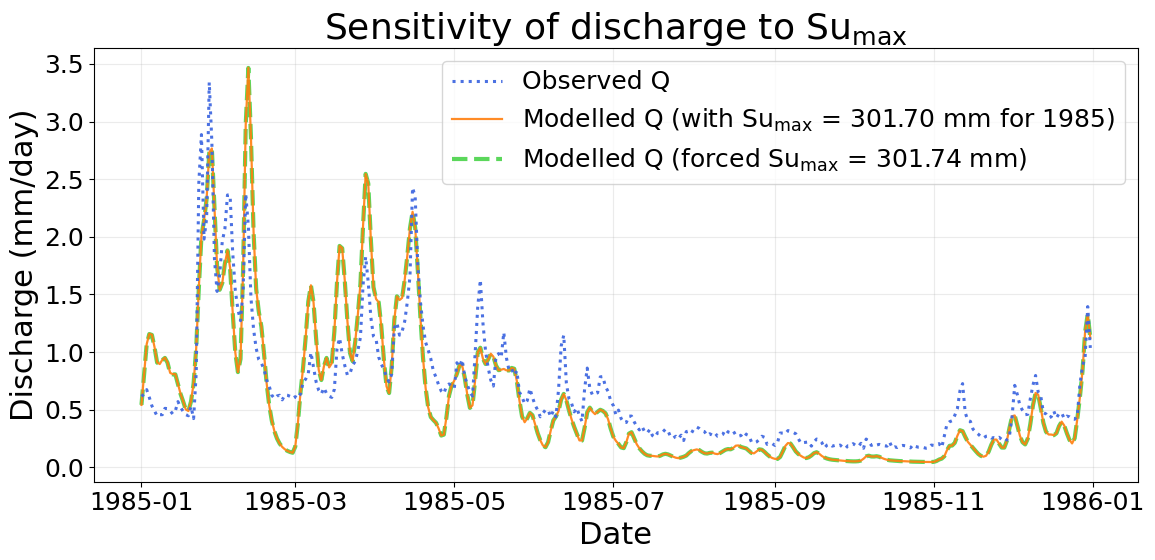

Lowest annual Su_max year: 1985 | Su_max = 301.697 mm
Max annual Su_max year: 2014 | Su_max = 301.739 mm


In [87]:
# Discharge time series for the year with lowest annual Su_max
# Lines shown:
# 1) Observed discharge
# 2) Modelled discharge with calculated (best-run) Su_max
# 3) Modelled discharge with forced max-Su_max condition in that same year

if 'daily_forcing' not in globals():
    raise RuntimeError('Run daily forcing setup first so daily_forcing exists.')
if 'q_obs_daily' not in globals() or 'sim_daily_best_slow' not in globals():
    raise RuntimeError('Run the slow-gamma calibration cell first to create q_obs_daily and sim_daily_best_slow.')
if 'best_daily_slow' not in globals() or 'pr_da_mc' not in globals() or 'pet_da_mc' not in globals():
    raise RuntimeError('Run the calibration setup cell first so best parameters and forcing DataArrays exist.')

# Build annual Su_max from the best run (use the same signal as your annual Su_max plot)
best_Sumax0 = float(best_daily_slow['params'][2])
best_gamma = float(best_daily_slow['params'][8])
if abs(best_gamma) < 1e-12:
    raise RuntimeError('Gamma is too close to zero; cannot map a target Su_max back to temperature anomaly.')

if 'delT_C' in daily_forcing.columns:
    su_signal_for_year_pick = daily_forcing['delT_C']
else:
    raise RuntimeError("daily_forcing['delT_C'] is required.")

best_daily_su_local = best_Sumax0 + best_gamma * su_signal_for_year_pick
annual_su_local = best_daily_su_local.resample('YE').mean()

low_year = int(annual_su_local.idxmin().year)
max_year = int(annual_su_local.idxmax().year)
max_su_value = float(annual_su_local.max())

# Build observed and baseline simulated discharge series
full_index = daily_forcing.index
q_obs_series = pd.Series(np.asarray(q_obs_daily, dtype=float), index=full_index)
q_sim_best_series = pd.Series(np.asarray(sim_daily_best_slow, dtype=float), index=full_index)

# Create a counterfactual temperature-anomaly signal for model rerun:
# in the low-Su_max year, force Su_max to the max annual Su_max value
if 'daily_forcing_slow' in globals() and 'delT_slow_C' in daily_forcing_slow.columns:
    model_tas_signal = daily_forcing_slow['delT_slow_C'].reindex(full_index).copy()
else:
    model_tas_signal = daily_forcing['delT_C'].copy()

tas_forced_value = (max_su_value - best_Sumax0) / best_gamma
model_tas_counterfactual = model_tas_signal.copy()
model_tas_counterfactual.loc[model_tas_counterfactual.index.year == low_year] = tas_forced_value

tas_da_counter = xr.DataArray(
    model_tas_counterfactual.to_numpy(dtype=float),
    coords={'time': full_index},
    dims=('time',),
    name='tas',
)

cfg_counter = {
    'precipitation_file': pr_da_mc,
    'potential_evaporation_file': pet_da_mc,
    'temperature_file': tas_da_counter,
    'T_baseline': 0.0,
    'initial_storage': '0.0,100.0,0.0,5.0',
}

m_counter = HBV_Bmi()
m_counter.initialize(cfg_counter)
m_counter.set_pars(best_daily_slow['params'])

sim_counter = []
while m_counter.current_timestep < m_counter.end_timestep:
    m_counter.update()
    out = np.array([0.0])
    m_counter.get_value('Q', out)
    sim_counter.append(out[0])
sim_counter = np.asarray(sim_counter, dtype=float)
q_sim_counter_series = pd.Series(sim_counter, index=full_index)

# Slice the selected low-Su_max year
year_mask = full_index.year == low_year
plot_index = full_index[year_mask]
obs_year = q_obs_series.loc[plot_index]
sim_best_year = q_sim_best_series.loc[plot_index]
sim_counter_year = q_sim_counter_series.loc[plot_index]

plt.figure(figsize=(12, 6))
plt.plot(plot_index, obs_year.values,
         color='royalblue', linestyle=':', linewidth=2.2, alpha=0.95, zorder=4,
         label='Observed Q')

plt.plot(plot_index, sim_best_year.values,
         color='tab:orange', linestyle='-', linewidth=1.6, alpha=0.9, zorder=2,
         label=f'Modelled Q (with $\mathrm{{Su}}_{{\max}}$ = {annual_su_local.min():.2f} mm for 1985)')

plt.plot(plot_index, sim_counter_year.values,
         color='limegreen', linestyle='--', linewidth=3.0, alpha=0.8, zorder=1,
         label=f'Modelled Q (forced $\mathrm{{Su}}_{{\max}}$ = {max_su_value:.2f} mm)')

plt.title('Sensitivity of discharge to $\mathrm{Su_{max}}$')
plt.xlabel('Date')
plt.ylabel('Discharge (mm/day)')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Lowest annual Su_max year: {low_year} | Su_max = {annual_su_local.min():.3f} mm')
print(f'Max annual Su_max year: {max_year} | Su_max = {max_su_value:.3f} mm')

To see whether a seemingly small differece in $Su_{max}$ (0.04 mm) makes a difference to the moddlled discharge, we plot the above graph, where we used the highest (1985) and smallest (2014) $Su_{max}$ on to model discharge for 1985. The orange and green lines are visually identical, indicating that discharge is insensitive to the range of $Su_{max}$ values obtained. 